# BlinkIT Grocery Data Analytics Project

## Exploratory Data Analysis (EDA)

### Objective

The goal of this phase is to explore the cleaned dataset, identify patterns, generate insights, and understand business behavior through visualizations.

## Business Questions

- Which products generate the highest sales?
- Which product categories perform best?
- Which outlet type performs best?
- Does outlet location affect sales?
- Does product pricing influence sales?
- Does product visibility affect sales?
- Which factors have the strongest relationship with sales?
- Are there patterns that can improve business performance?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Dataset/blinkit_cleaned_dataset.csv')

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Dataset Overview

### Understanding the structure and dimensions of the cleaned dataset.

In [3]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (8499, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8499 entries, 0 to 8498
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8499 non-null   str    
 1   Item_Weight                8499 non-null   float64
 2   Item_Fat_Content           8499 non-null   str    
 3   Item_Visibility            8499 non-null   float64
 4   Item_Type                  8499 non-null   str    
 5   Item_MRP                   8499 non-null   float64
 6   Outlet_Identifier          8499 non-null   str    
 7   Outlet_Establishment_Year  8499 non-null   int64  
 8   Outlet_Size                8499 non-null   str    
 9   Outlet_Location_Type       8499 non-null   str    
 10  Outlet_Type                8499 non-null   str    
 11  Item_Outlet_Sales          8499 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 796.9 KB


## Statistical Summary

### Understanding numerical columns and identifying overall patterns in the dataset.

In [5]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8499.000000,8499.000000,8499.000000,8499.000000,8499.000000
mean,12.812489,0.066094,140.978389,1997.833157,2182.437015
std,4.216831,0.051595,62.058466,8.372895,1706.260802
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.395000,0.026983,94.044900,1987.000000,834.913200
50%,12.600000,0.053887,142.931200,1999.000000,1796.328400
75%,16.000000,0.094488,185.359500,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [6]:
(df['Outlet_Establishment_Year'] > 2025).sum()

np.int64(0)

## Establishment Year Validation

### Removing unrealistic future establishment years from the dataset.

In [7]:
df = df[df['Outlet_Establishment_Year'] <= 2025]

(df['Outlet_Establishment_Year'] > 2025).sum()

np.int64(0)

In [8]:
df.to_csv('../Dataset/blinkit_cleaned_dataset.csv', index=False)

print("Updated cleaned dataset saved successfully")

Updated cleaned dataset saved successfully


## Univariate Analysis

### Analyzing individual variables to understand distribution and patterns.

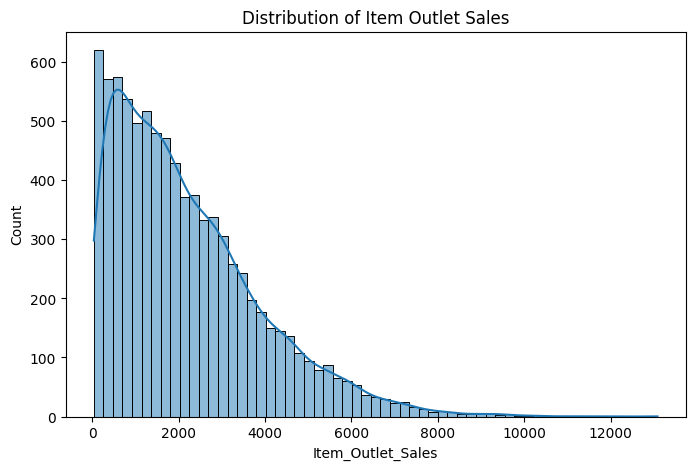

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Item_Outlet_Sales'], kde=True)

plt.title('Distribution of Item Outlet Sales')
plt.show()

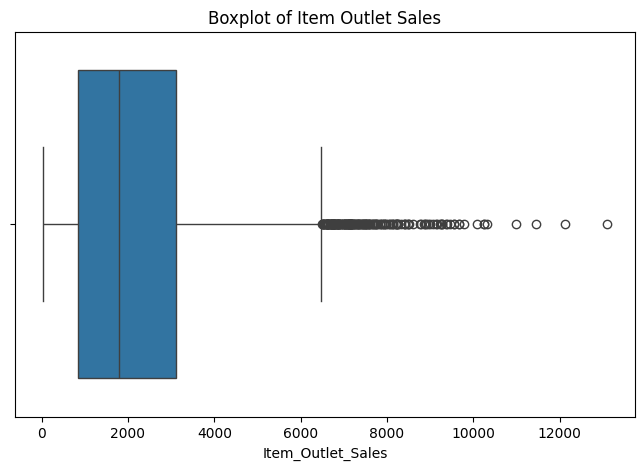

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Item_Outlet_Sales'])

plt.title('Boxplot of Item Outlet Sales')
plt.show()

### Insight

- Multiple high-value sales outliers are present.
- These values may represent high-performing products.
- Outliers were retained because they represent potential business behavior rather than incorrect data.

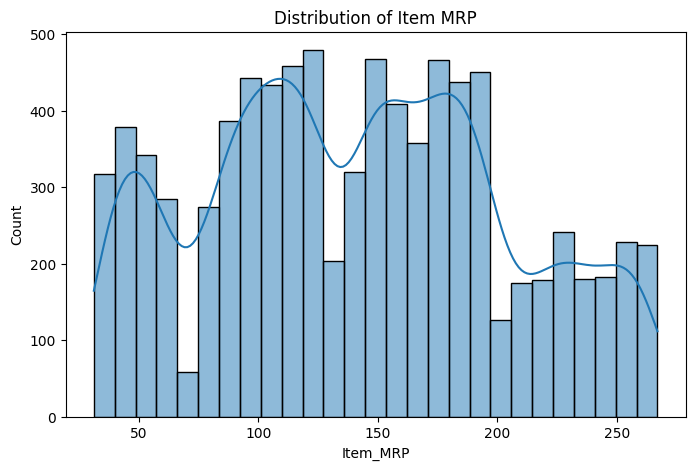

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Item_MRP'], kde=True)

plt.title('Distribution of Item MRP')
plt.show()

### Insight

- Item MRP shows a multi-modal distribution.
- Multiple product pricing segments exist.
- Product prices appear realistic without major anomalies.

## Bivariate Analysis

### Analyzing relationships between two variables to understand business behavior and patterns.

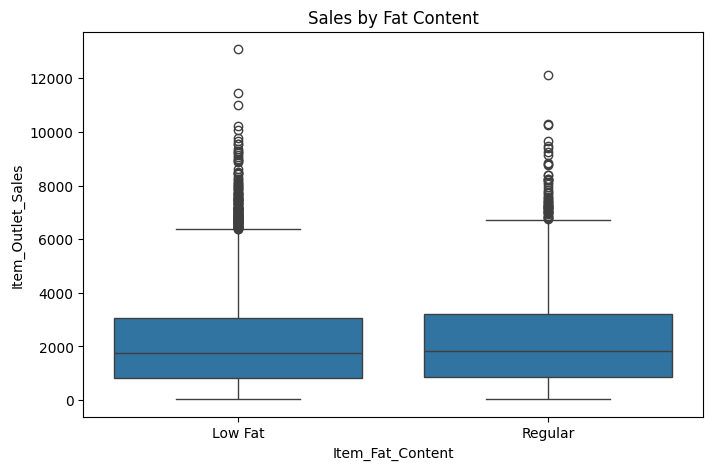

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Item_Fat_Content',
    y='Item_Outlet_Sales',
    data = df 
)

plt.title('Sales by Fat Content')
plt.show()

### Insight

- Regular products show slightly higher median sales.
- Both categories have similar sales distributions.
- Fat content alone may not strongly influence sales performance.
- High-performing products exist in both categories.

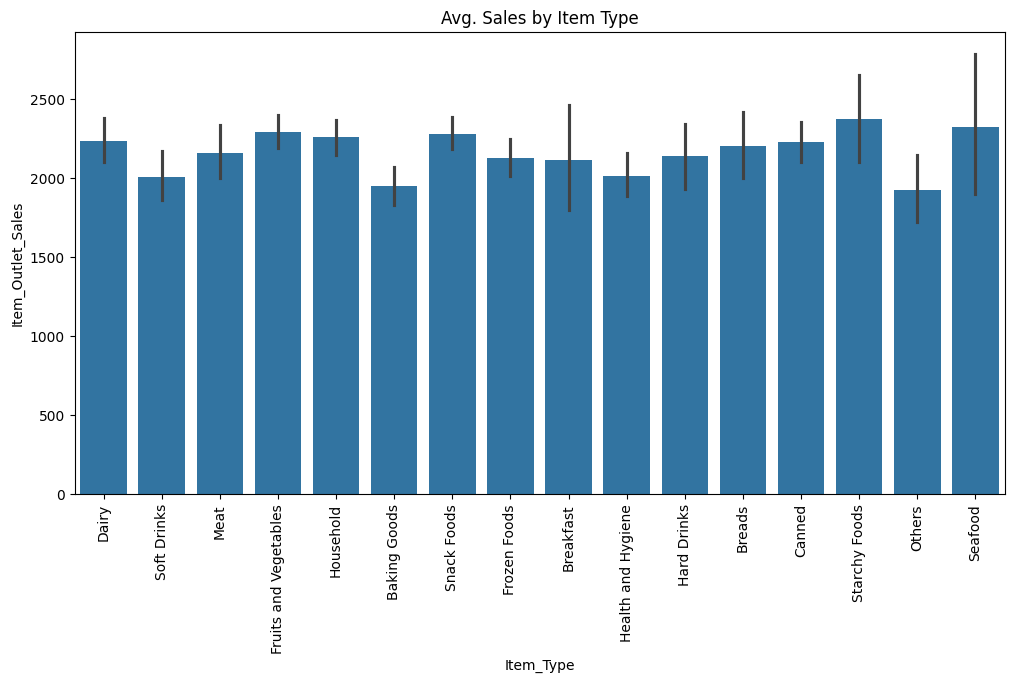

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Item_Type',
    y='Item_Outlet_Sales',
    data = df
)

plt.xticks(rotation=90)
plt.title('Avg. Sales by Item Type')
plt.show()

### Insight

- Starchy Foods and Seafood show higher average sales.
- Baking Goods and Others show lower average sales.
- Product category appears to have a stronger influence on sales than fat content.

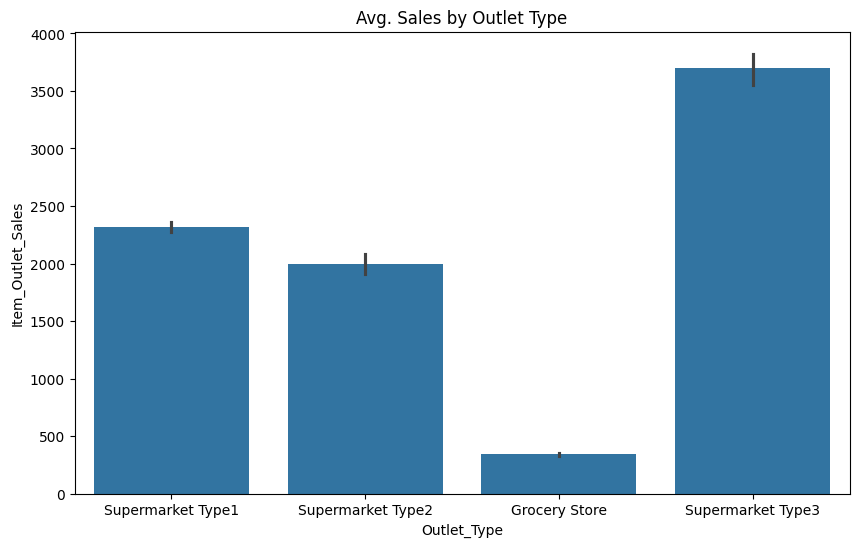

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Outlet_Type',
    y='Item_Outlet_Sales',
    data = df
)

plt.title('Avg. Sales by Outlet Type')
plt.show()

### Insight

- Supermarket Type3 generates the highest average sales.
- Grocery Stores show the lowest average sales performance.
- Outlet type appears to strongly influence overall sales.

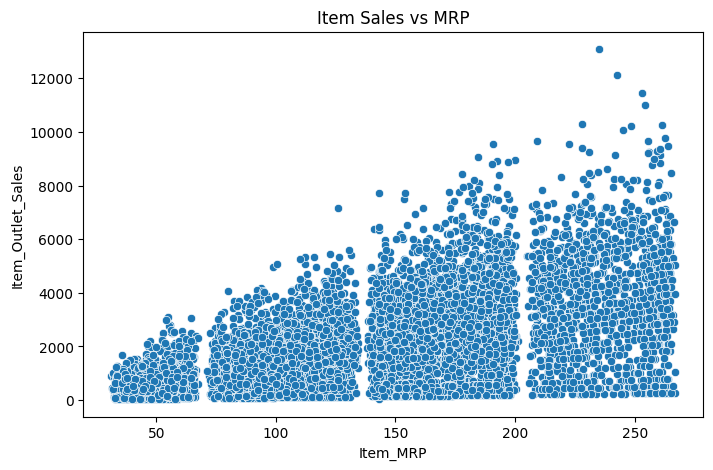

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Item_MRP',
    y='Item_Outlet_Sales',
    data = df
)

plt.title('Item Sales vs MRP')
plt.show()

## Correlation Analysis

### Measuring how numerical variables relate to each other.

In [16]:
correlation = df[[
    'Item_Weight',
    'Item_Visibility',
    'Item_MRP',
    'Item_Outlet_Sales'
]].corr()

correlation

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
Item_Weight,1.000000,-0.015014,0.025668,0.010152
Item_Visibility,-0.015014,1.000000,-0.001519,-0.129292
Item_MRP,0.025668,-0.001519,1.000000,0.565813
Item_Outlet_Sales,0.010152,-0.129292,0.565813,1.000000


## Correlation Heatmap

### Visualizing relationships between numerical variables.

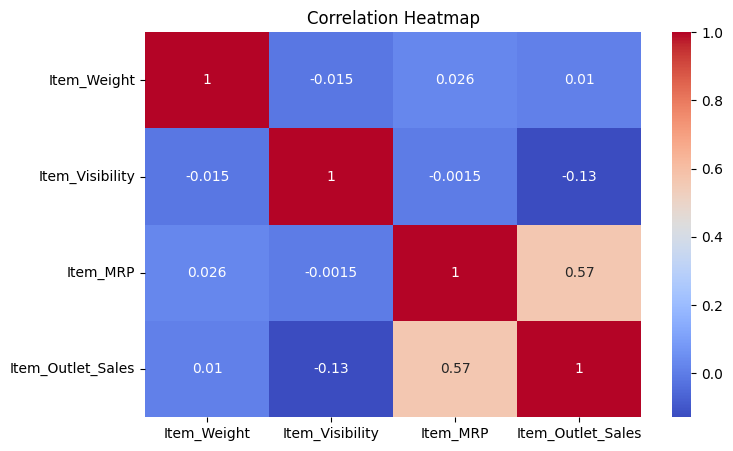

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
)
plt.title('Correlation Heatmap')
plt.show()

## Sales by Outlet Location

### Analyzing whether outlet location type influences average sales performance.

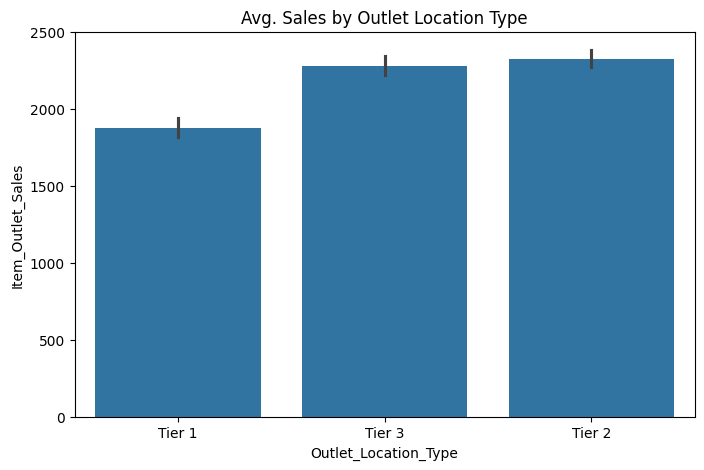

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Outlet_Location_Type",
    y='Item_Outlet_Sales',
    data = df
)

plt.title('Avg. Sales by Outlet Location Type')
plt.show()

### Insight

- Tier 2 locations generate the highest average sales.
- Tier 1 locations show lower sales performance.
- Outlet type appears to influence sales more strongly than location type.

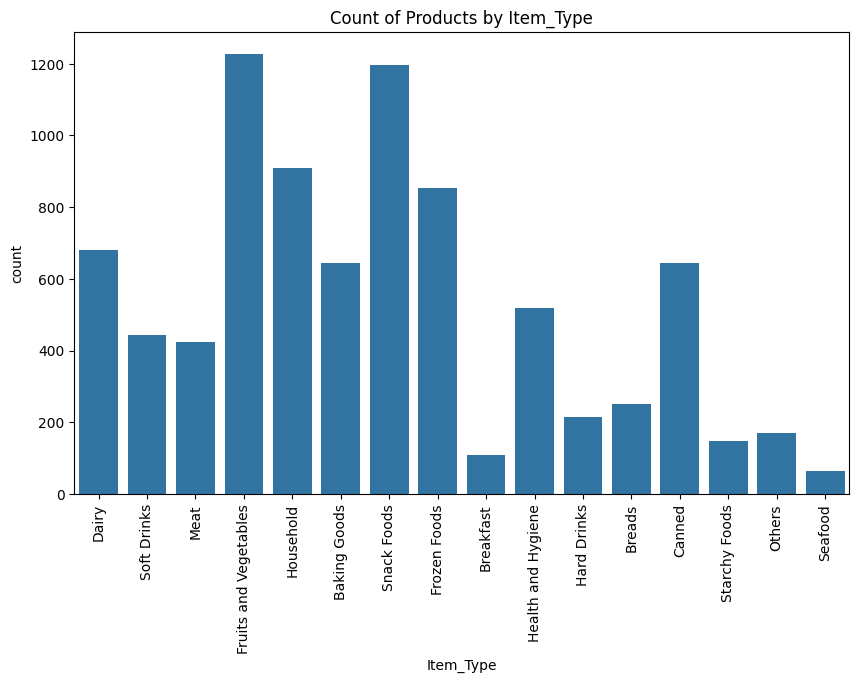

In [19]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Item_Type',
    data = df
)

plt.xticks(rotation=90 )
plt.title('Count of Products by Item_Type')
plt.show()

### Insight

- Fruits and Vegetables and Snack Foods have the highest product counts.
- Seafood has relatively few products but showed strong average sales.
- Product frequency and product performance are not always the same.

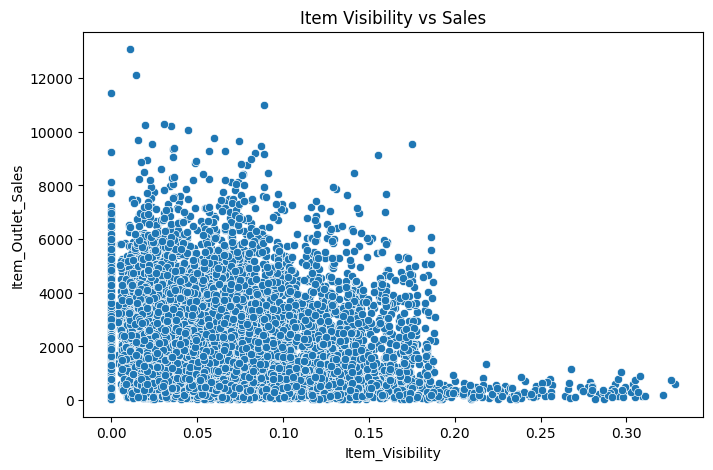

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Item_Visibility',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Item Visibility vs Sales')

plt.show()

### Insight

- Higher visibility does not necessarily lead to higher sales.
- Most high-sales products appear at lower visibility levels.
- Visibility alone does not strongly influence sales performance.

## Outlet Age Analysis

### Checking whether older outlets generate higher sales performance.

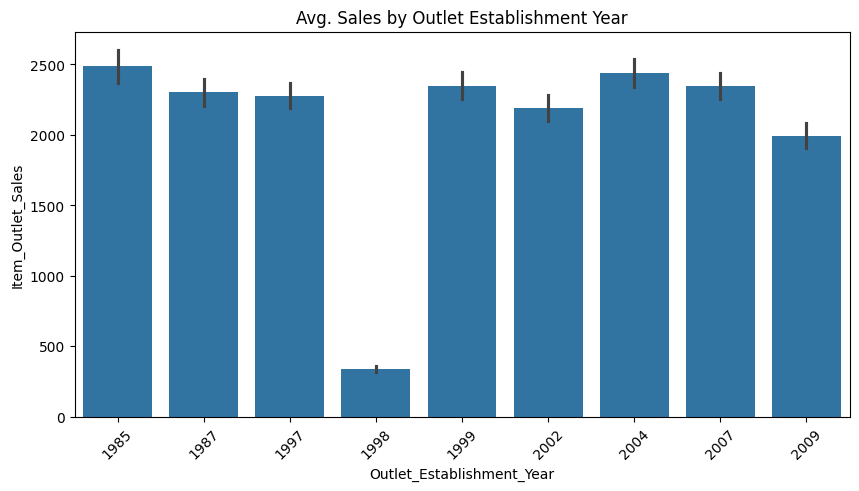

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Outlet_Establishment_Year',
    y='Item_Outlet_Sales',
    data=df
)

plt.xticks(rotation=45)
plt.title('Avg. Sales by Outlet Establishment Year')
plt.show()

### Insight

- No strong relationship exists between outlet age and sales performance.
- Some specific outlet years perform better than others.
- Year 1998 shows unusually low average sales and may require deeper investigation.

In [22]:
df[df['Outlet_Establishment_Year'] == 1998]['Outlet_Type'].value_counts()

Outlet_Type
Grocery Store    551
Name: count, dtype: int64

### Investigation Insight

- Year 1998 showed unusually low sales.
- Investigation revealed all 1998 outlets are Grocery Stores.
- Outlet Type appears to influence sales more strongly than outlet age.

## Sales by Outlet Size

### Analyzing whether outlet size influences sales performance.

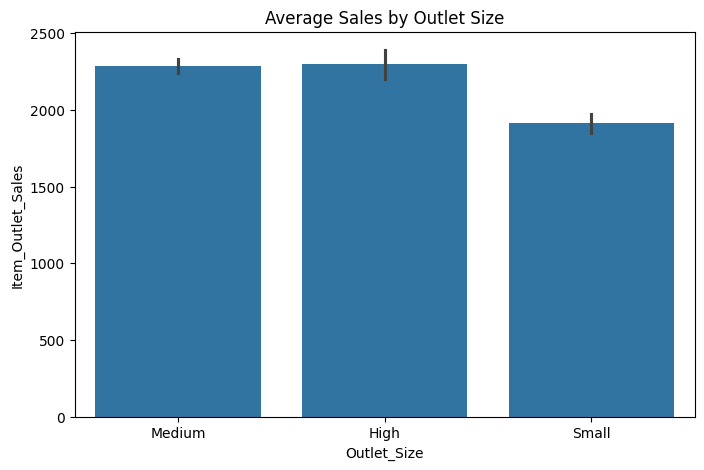

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Outlet_Size',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Average Sales by Outlet Size')

plt.show()

### Insight

- High and Medium outlets show similar sales performance.
- Small outlets generate comparatively lower sales.
- Outlet characteristics appear to influence sales more strongly than product characteristics.

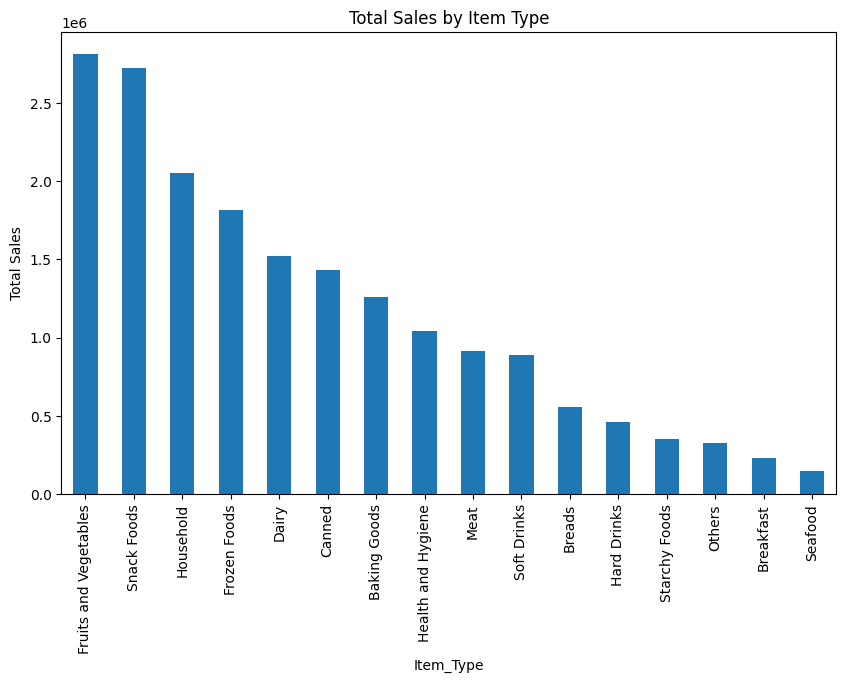

In [24]:
top_products = df.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title('Total Sales by Item Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

### Insight

- Fruits and Vegetables contribute the highest total sales.
- Snack Foods and Household products also perform strongly.
- Seafood shows high average sales but lower total sales due to fewer products.
- Product count and average performance together influence total revenue.

## Sales Contribution by Outlet Type

### Analyzing total sales contribution across different outlet types.

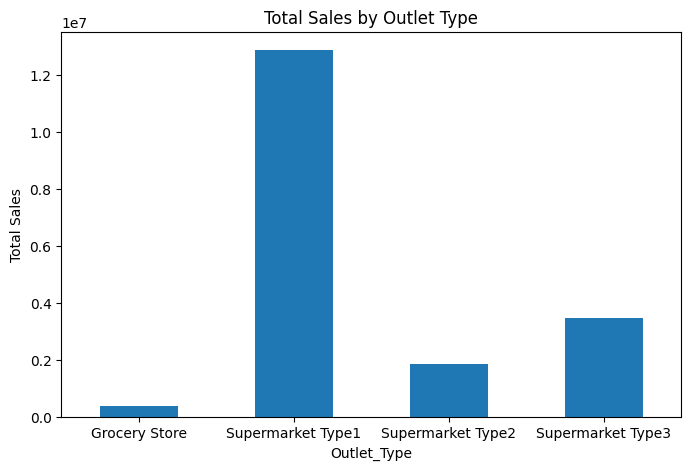

In [26]:
outlet_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'].sum()
plt.figure(figsize=(8,5))
outlet_sales.plot(kind='bar')
plt.title('Total Sales by Outlet Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()


### Insight

- Supermarket Type1 contributes the highest total sales.
- Supermarket Type3 had higher average sales but lower overall contribution.
- Total revenue depends on both sales performance and transaction volume.
- Grocery Stores contribute the least to overall sales.

## Total Sales by Outlet Location

### Analyzing overall sales contribution across different location tiers.


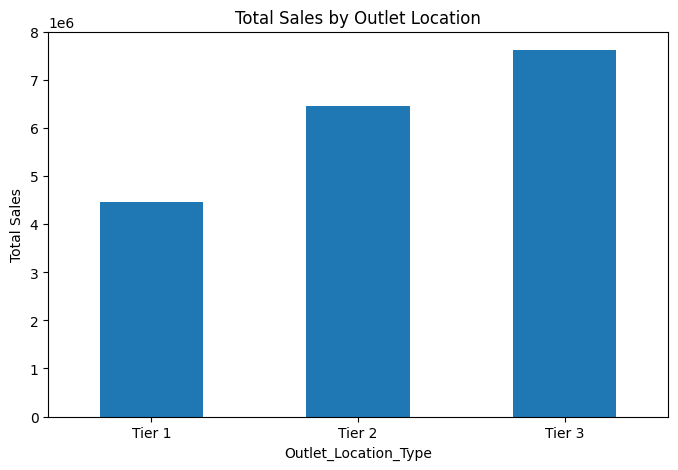

In [27]:
location_sales = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].sum()
plt.figure(figsize=(8,5))
location_sales.plot(kind='bar')
plt.title('Total Sales by Outlet Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()


### Insight

- Tier 3 contributes the highest total sales.
- Tier 2 showed stronger average sales but lower overall contribution.
- Total revenue depends on both performance and volume.
- Tier 1 locations consistently show lower contribution.

## Multivariate Analysis

### Understanding how multiple variables together influence sales performance.

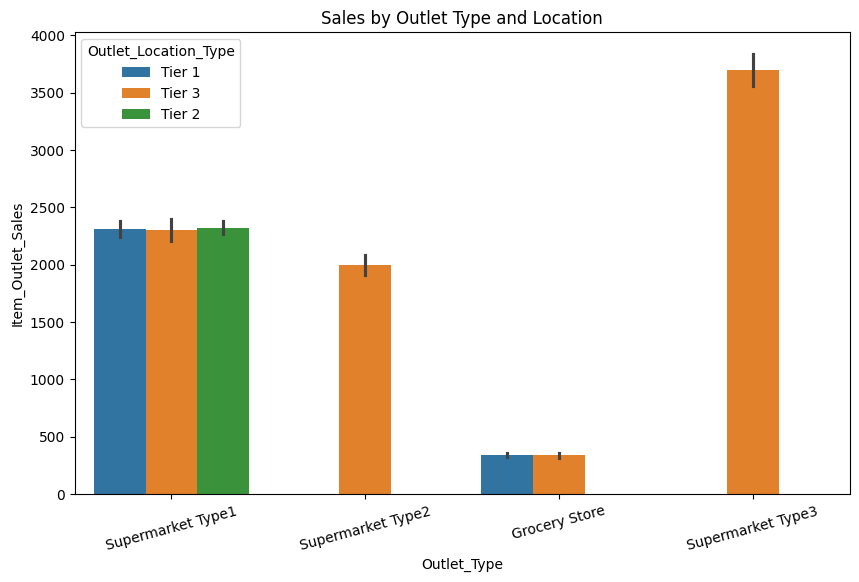

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Outlet_Type',
    y='Item_Outlet_Sales',
    hue="Outlet_Location_Type",
    data = df
)

plt.xticks(rotation=15)
plt.title('Sales by Outlet Type and Location')
plt.show()

### Insight

- Supermarket Type3 in Tier3 shows the highest sales performance.
- Grocery Stores show low performance across locations.
- Supermarket Type1 maintains relatively stable performance across locations.
- Outlet type appears to influence sales more strongly than location.

## Key Performance Indicators (KPIs)

### Calculating important business metrics from the dataset.

In [31]:
total_sales = df['Item_Outlet_Sales'].sum()
avg_sales = df['Item_Outlet_Sales'].mean()
avg_mrp = df['Item_MRP'].mean()

total_products = df['Item_Identifier'].nunique()
total_outlets = df['Outlet_Identifier'].nunique()

print(f"Total Sales: {round(total_sales, 2)}")
print(f"Average Sales: {round(avg_sales, 2)}")
print(f"Average MRP: {round(avg_mrp, 2)}")
print(f"Total Products: {total_products}")
print(f"Total Outlets: {total_outlets}")

Total Sales: 18548532.19
Average Sales: 2182.44
Average MRP: 140.98
Total Products: 1559
Total Outlets: 10


### KPI Insights

- Total sales generated are approximately ₹18.5M.
- Average sales per record are ₹2.18K.
- Average product price is ₹140.98.
- The dataset contains 1559 unique products.
- Sales are distributed across 10 unique outlets.

# Final EDA Summary

## Key Findings

### Product Insights
- Fruits and Vegetables generated the highest total sales.
- Snack Foods and Household products also performed strongly.
- Seafood showed high average sales but lower total sales due to fewer products.

### Outlet Insights
- Supermarket Type3 showed the highest average sales.
- Supermarket Type1 generated the highest total revenue.
- Grocery Stores showed the lowest sales performance.

### Location Insights
- Tier 3 contributed the highest total sales.
- Tier 2 showed slightly better average sales performance.

### Product Characteristics
- Item MRP showed a moderate positive relationship with sales.
- Item Visibility showed a weak relationship with sales.
- Fat Content had minimal influence on sales performance.

### Overall Business Pattern
- Outlet-related factors influence sales more strongly than product-related factors.

# Business Recommendations

## Recommendations

- Increase inventory and promotions for high-performing categories such as Fruits and Vegetables and Snack Foods.

- Analyze and replicate strategies used by Supermarket Type3 outlets.

- Focus business expansion toward high-performing Tier locations.

- Investigate low-performing Grocery Stores for possible improvements.

- Use pricing strategies since Item MRP showed a meaningful relationship with sales.

- Review product visibility placement because higher visibility alone did not guarantee higher sales.